<a href="https://colab.research.google.com/github/Xtian76/TFM-ISBI/blob/main/Dia_6_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Montar Google Drive en Colab

El primer paso es montar tu Google Drive. Ejecuta el siguiente código y sigue las instrucciones para autorizar el acceso.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Una vez que hayas montado tu Drive, tus archivos estarán accesibles en la ruta `/content/drive/My Drive/`. Puedes adaptar tu código para usar esta ruta. Por ejemplo, si tus archivos están en una carpeta llamada `mis_datos` dentro de tu Drive, la ruta sería `/content/drive/My Drive/mis_datos`.

Basado en el código que proporcionaste, puedes modificarlo de la siguiente manera:

In [4]:
import os

# Cambia "Path to dataset files:" por la ruta real de tu carpeta en Google Drive
# Por ejemplo, si tus datos están en "My Drive/dia1-5/datasets"
DATA_DIR = "/content/drive/MyDrive/TFM ISBI/Copia de dia 1-5.ipynb"
OUTPUT_DIR = "/content/drive/My Drive/dia1-5/outputs_week1"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

DATA_DIR: /content/drive/MyDrive/TFM ISBI/Copia de dia 1-5.ipynb
OUTPUT_DIR: /content/drive/My Drive/dia1-5/outputs_week1


Recuerda reemplazar `/content/drive/My Drive/dia1-5/datasets` con la ruta real a tus archivos de datos en Google Drive. Con esto, podrás continuar trabajando en otro cuaderno de Colab usando tus archivos de Drive y un código similar.

### Paso 1: Carga de datos

Cargaremos los datos desde un archivo. **Asegúrate de reemplazar `'nombre_de_tu_archivo_de_datos.csv'` con la ruta y el nombre real de tu archivo de datos** (por ejemplo, `/content/drive/MyDrive/TFM ISBI/tus_datos.csv`).

In [19]:
import pandas as pd

# Define la ruta a tu archivo de datos. Reemplaza 'nombre_de_tu_archivo_de_datos.csv'
# con la ruta y nombre real de tu archivo.
data_file_path = "/content/drive/MyDrive/TFM ISBI/extraccion de biomarcadores.ods"

try:
    # Intenta cargar el archivo ODS usando read_excel
    # Puedes necesitar instalar 'odfpy' o 'ezodf' si hay problemas
    # !pip install odfpy
    df = pd.read_excel(data_file_path, engine='odf') # Usamos engine='odf' para archivos .ods
    print("Datos cargados exitosamente.")
    # Muestra las primeras filas y la información del DataFrame
    display(df.head())
    df.info()
except FileNotFoundError:
    print(f"Error: El archivo no fue encontrado en la ruta especificada: {data_file_path}")
    print("Por favor, verifica la ruta del archivo en Google Drive.")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Datos cargados exitosamente.


,"index,Subject_Scan,Total_Lesion_Volume_mm3,Number_of_Mask_Files,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity"
0,"0,training05_02,6031.0,2,9.896466556764785e-17..."
1,"1,training05_03,5535.0,2,-1.1912983898561391e-..."
2,"2,training05_04,5455.0,2,-3.1652041208011797e-..."
3,"3,training05_01,5895.0,2,-1.4608614007485012e-..."
4,"4,training04_03,3856.0,2,7.370775267220956e-17..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 1 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype 
---  ------                                                                                                                              --------------  ----- 
 0   index,Subject_Scan,Total_Lesion_Volume_mm3,Number_of_Mask_Files,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity  21 non-null     object
dtypes: object(1)
memory usage: 300.0+ bytes


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('index,Subject_Scan,Total_Lesion_Volume_mm3,Number_of_Mask_Files,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

### Paso 5: Análisis de correlaciones

Calcularemos y visualizaremos la matriz de correlación entre las variables numéricas.

In [24]:
# Selecciona solo las columnas numéricas relevantes para la correlación
# Excluimos 'index' y 'Number_of_Mask_Files' ya que no parecen ser variables continuas relevantes para correlación
numeric_cols_for_corr = [
    'Total_Lesion_Volume_mm3',
    'Mean_Lesion_Intensity',
    'Std_Lesion_Intensity',
    'Median_Lesion_Intensity'
]

# Calcula la matriz de correlación
correlation_matrix = df_parsed[numeric_cols_for_corr].corr()

print("Matriz de Correlación:")
display(correlation_matrix)

Matriz de Correlación:


,Total_Lesion_Volume_mm3,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity
Total_Lesion_Volume_mm3,1.000000,-0.320748,0.721584,0.003968
Mean_Lesion_Intensity,-0.320748,1.000000,-0.039143,-0.215631
Std_Lesion_Intensity,0.721584,-0.039143,1.000000,-0.130647
Median_Lesion_Intensity,0.003968,-0.215631,-0.130647,1.000000


from matplotlib import pyplot as plt
_df_1['Total_Lesion_Volume_mm3'].plot(kind='hist', bins=20, title='Total_Lesion_Volume_mm3')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Mean_Lesion_Intensity'].plot(kind='hist', bins=20, title='Mean_Lesion_Intensity')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Std_Lesion_Intensity'].plot(kind='hist', bins=20, title='Std_Lesion_Intensity')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_14['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_14, x='Mean_Lesion_Intensity', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_15['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_15, x='Std_Lesion_Intensity', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_16['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_16, x='Median_Lesion_Intensity', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

### Paso 4: Análisis de distribución

Visualizaremos la distribución de las variables numéricas para entender su forma y posibles patrones.

Visualizando la distribución de columnas numéricas:


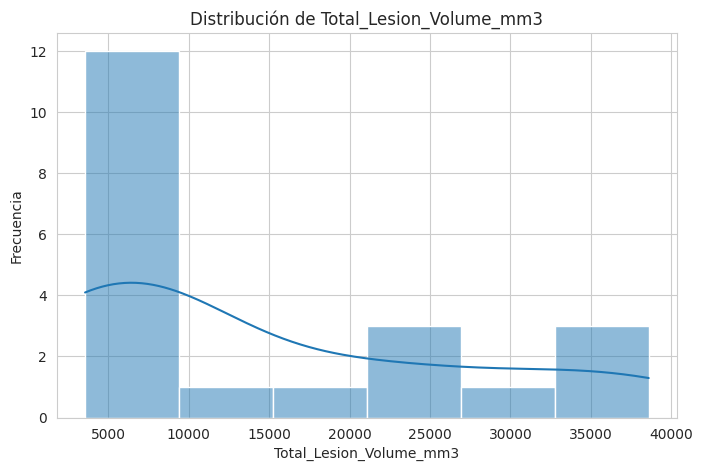

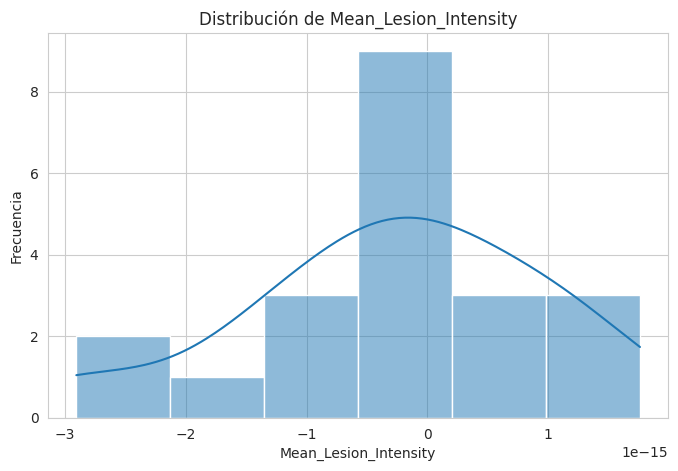

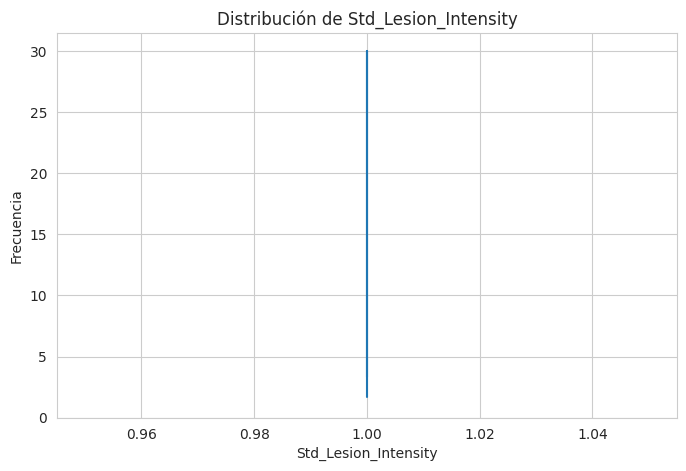

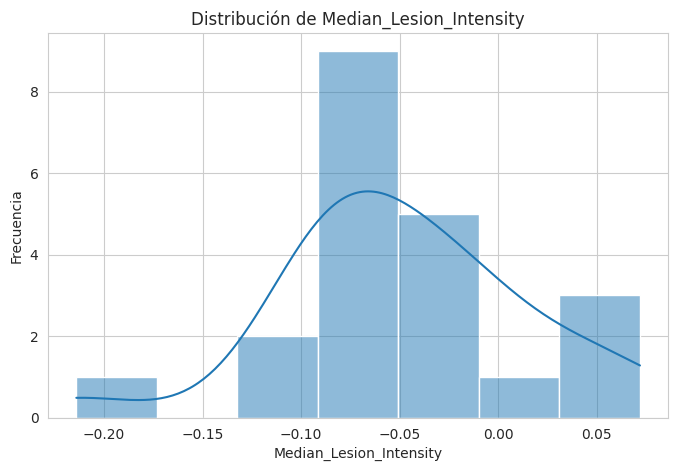

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols_for_dist = [
    'Total_Lesion_Volume_mm3',
    'Mean_Lesion_Intensity',
    'Std_Lesion_Intensity',
    'Median_Lesion_Intensity'
]

print("Visualizando la distribución de columnas numéricas:")

for col in numeric_cols_for_dist:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_parsed[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

### Paso 3: Análisis estadístico descriptivo

Realizaremos un análisis estadístico descriptivo de las columnas numéricas para obtener un resumen de sus características principales.

In [25]:
# Selecciona solo las columnas numéricas para el análisis descriptivo
# Excluimos la columna 'index' ya que suele ser solo un identificador
numeric_cols_for_desc = [
    'Total_Lesion_Volume_mm3',
    'Number_of_Mask_Files',
    'Mean_Lesion_Intensity',
    'Std_Lesion_Intensity',
    'Median_Lesion_Intensity'
]

print("Estadísticas descriptivas para columnas numéricas:")
display(df_parsed[numeric_cols_for_desc].describe())

Estadísticas descriptivas para columnas numéricas:


,Total_Lesion_Volume_mm3,Number_of_Mask_Files,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity
count,21.000000,21.0,2.100000e+01,2.100000e+01,21.000000
mean,14752.285714,2.0,-2.967337e-16,1.000000e+00,-0.049233
std,12364.285714,0.0,1.237806e-15,8.599751e-17,0.062852
min,3555.000000,2.0,-2.905430e-15,1.000000e+00,-0.214007
25%,5535.000000,2.0,-1.191298e-15,1.000000e+00,-0.080192
50%,7756.000000,2.0,-1.099344e-16,1.000000e+00,-0.059039
75%,21353.000000,2.0,7.977650e-16,1.000000e+00,-0.018233
max,38607.000000,2.0,1.759847e-15,1.000000e+00,0.071895


### Paso 2: Limpieza inicial y preparación (Parseo de Columnas)

Ahora que los datos están cargados, necesitamos separar la única columna que se leyó en las columnas correctas y convertir los tipos de datos.

In [26]:
# La columna actual se llama 'index,Subject_Scan,Total_Lesion_Volume_mm3,Number_of_Mask_Files,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity'
# Vamos a intentar dividir esta columna en varias columnas usando la coma como delimitador.

# Primero, obtenemos el nombre de la columna actual
single_column_name = df.columns[0]

# Dividimos la columna en múltiples columnas
# expand=True crea nuevas columnas a partir de los elementos divididos
df_parsed = df[single_column_name].str.split(',', expand=True)

# Asignamos nombres a las nuevas columnas
# Asegúrate de que estos nombres coincidan con los del archivo original
df_parsed.columns = [
    'index',
    'Subject_Scan',
    'Total_Lesion_Volume_mm3',
    'Number_of_Mask_Files',
    'Mean_Lesion_Intensity',
    'Std_Lesion_Intensity',
    'Median_Lesion_Intensity'
]

# Intentar convertir las columnas numéricas a tipos de datos adecuados
numeric_cols = [
    'index',
    'Total_Lesion_Volume_mm3',
    'Number_of_Mask_Files',
    'Mean_Lesion_Intensity',
    'Std_Lesion_Intensity',
    'Median_Lesion_Intensity'
]

for col in numeric_cols:
    # Usamos errors='coerce' para convertir valores que no son números a NaN (Not a Number)
    df_parsed[col] = pd.to_numeric(df_parsed[col], errors='coerce')

print("Datos parseados y tipos de datos convertidos.")

# Muestra las primeras filas y la información del nuevo DataFrame
display(df_parsed.head())
df_parsed.info()

Datos parseados y tipos de datos convertidos.


,index,Subject_Scan,Total_Lesion_Volume_mm3,Number_of_Mask_Files,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity
0,0,training05_02,6031.0,2,9.896467e-17,1.0,-0.104850
1,1,training05_03,5535.0,2,-1.191298e-15,1.0,0.006044
2,2,training05_04,5455.0,2,-3.165204e-16,1.0,-0.059039
3,3,training05_01,5895.0,2,-1.460861e-15,1.0,-0.074636
4,4,training04_03,3856.0,2,7.370775e-17,1.0,0.049150


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   index                    21 non-null     int64  
 1   Subject_Scan             21 non-null     object 
 2   Total_Lesion_Volume_mm3  21 non-null     float64
 3   Number_of_Mask_Files     21 non-null     int64  
 4   Mean_Lesion_Intensity    21 non-null     float64
 5   Std_Lesion_Intensity     21 non-null     float64
 6   Median_Lesion_Intensity  21 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 1.3+ KB


### Paso 6: Análisis de outliers y valores faltantes (en datos de lesiones)

Identificaremos y revisaremos los valores faltantes y posibles outliers en las columnas numéricas de los datos de lesiones.

In [27]:
print("Conteo de valores faltantes por columna:")
display(df_parsed.isnull().sum())

# Identificación básica de outliers usando el rango intercuartílico (IQR) para 'Total_Lesion_Volume_mm3'
# Esto es un ejemplo básico, se pueden usar métodos más sofisticados si es necesario.

Q1 = df_parsed['Total_Lesion_Volume_mm3'].quantile(0.25)
Q3 = df_parsed['Total_Lesion_Volume_mm3'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_parsed[(df_parsed['Total_Lesion_Volume_mm3'] < lower_bound) | (df_parsed['Total_Lesion_Volume_mm3'] > upper_bound)]

print("\nPosibles outliers en 'Total_Lesion_Volume_mm3' (usando método IQR):")
display(outliers)

# Nota: Puedes repetir este análisis para otras columnas numéricas si lo deseas.

Conteo de valores faltantes por columna:


,0
index,0
Subject_Scan,0
Total_Lesion_Volume_mm3,0
Number_of_Mask_Files,0
Mean_Lesion_Intensity,0
Std_Lesion_Intensity,0
Median_Lesion_Intensity,0



Posibles outliers en 'Total_Lesion_Volume_mm3' (usando método IQR):


,index,Subject_Scan,Total_Lesion_Volume_mm3,Number_of_Mask_Files,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity


### Paso 10: Heatmap de correlación (en datos de lesiones)

Visualizaremos la matriz de correlación calculada previamente como un heatmap para una mejor interpretación visual.

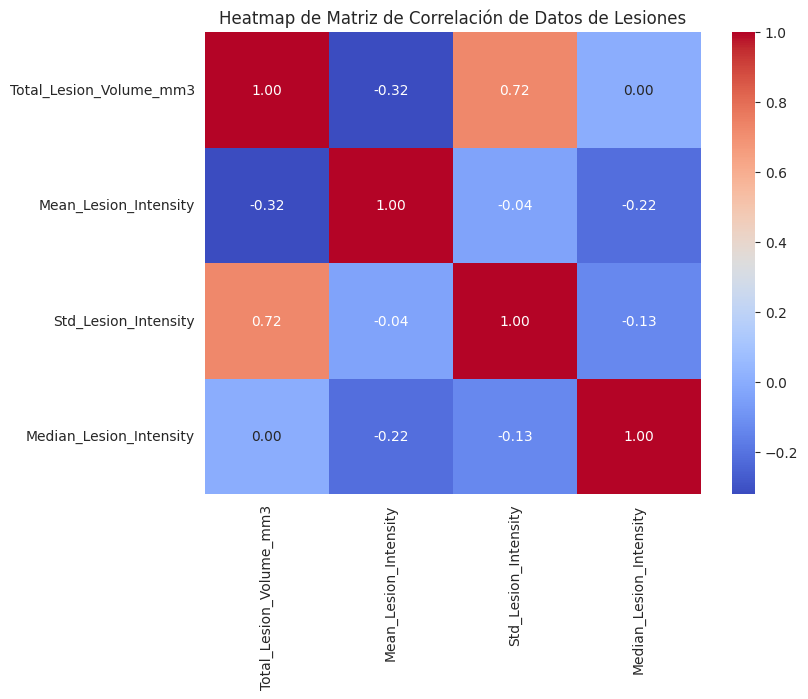

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegúrate de que la matriz de correlación 'correlation_matrix' del Paso 5 esté disponible
# Si no, ejecuta la celda del Paso 5 nuevamente.

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap de Matriz de Correlación de Datos de Lesiones')
plt.show()

In [20]:
!pip install odfpy